11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Running experiment with ReLU activation ---
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8774 - loss: 0.4265 - val_accuracy: 0.9625 - val_loss: 0.1288
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9694 - loss: 0.1017 - val_accuracy: 0.9748 - val_loss: 0.0866
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9789 - loss: 0.0703 - val_accuracy: 0.9751 - val_loss: 0.0775
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9844 - loss: 0.0490 - val_accuracy: 0.9753 - val_loss: 0.0818
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9872 - loss: 0.0411 - val_accuracy: 0.9762 - val_loss: 0.0781
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9893 - loss: 0.0330 - val_accuracy: 0.9742 - val_loss: 0.0841
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9912 - loss: 0.0276 - val_accuracy: 0.9780 - val_

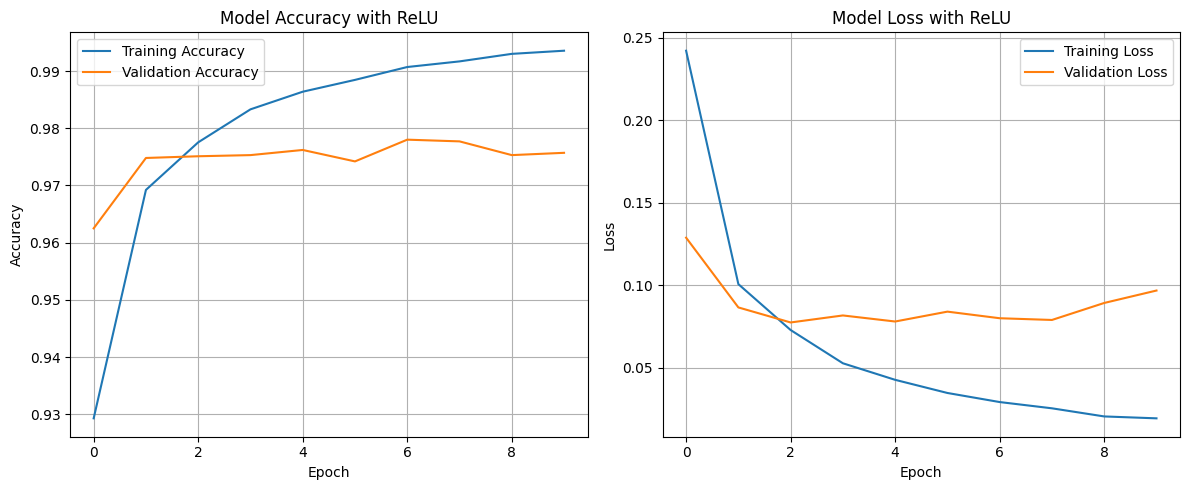


--- Running experiment with Sigmoid activation ---
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7947 - loss: 0.8417 - val_accuracy: 0.9379 - val_loss: 0.2121
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9439 - loss: 0.1913 - val_accuracy: 0.9573 - val_loss: 0.1429
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9628 - loss: 0.1295 - val_accuracy: 0.9671 - val_loss: 0.1114
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9712 - loss: 0.0944 - val_accuracy: 0.9723 - val_loss: 0.0924
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9796 - loss: 0.0694 - val_accuracy: 0.9725 - val_loss: 0.0870
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9833 - loss: 0.0557 - val_accuracy: 0.9750 - val_loss: 0.0813
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9870 - loss: 0.0434 - val_accuracy: 0.9758 - val_loss: 0.0859
Epoch 8/10
1875/1875 ━━━━━━━━━━━━

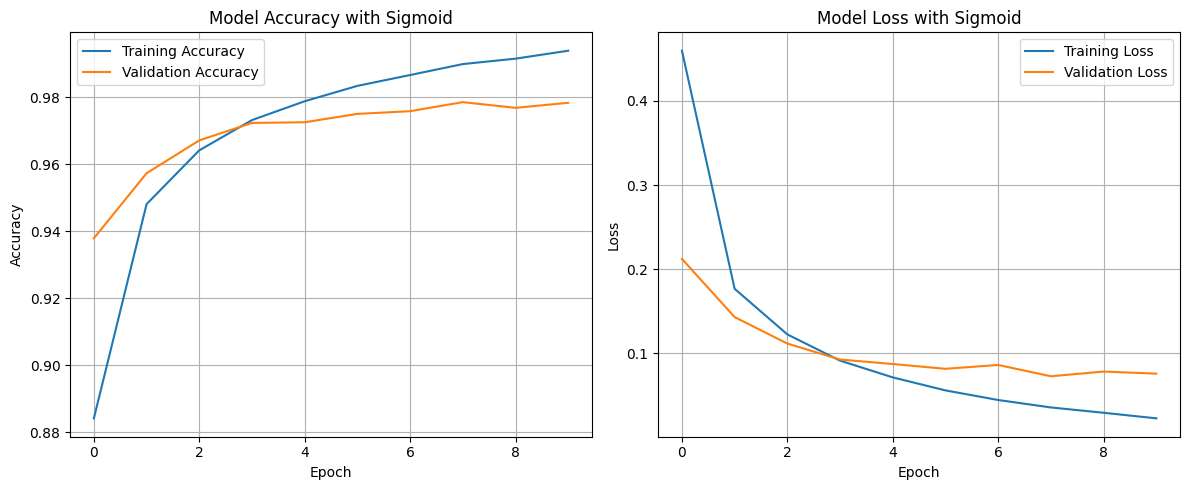

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Load and Prepare the MNIST Dataset ---
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

# Normalize pixel values from 0-255 to 0-1
train_images = train_images / 255.0
test_images = test_images / 255.0

# Flatten the 28x28 images into a 784-element vector
train_images = train_images.reshape(train_images.shape[0], 28 * 28)
test_images = test_images.reshape(test_images.shape[0], 28 * 28)

# --- 2. Function to Build, Train, and Evaluate the Model ---
def run_experiment(activation_function_name, activation_function):
    print(f"\n--- Running experiment with {activation_function_name} activation ---")

    # --- 3. Build the Neural Network Model ---
    # To remove the UserWarning, we use keras.Input() as the first layer.
    model = keras.Sequential([
        keras.Input(shape=(784,)), # Explicitly define the input layer
        keras.layers.Dense(128, activation=activation_function),
        keras.layers.Dense(64, activation=activation_function),
        keras.layers.Dense(10, activation='softmax')
    ])

    # --- 4. Compile the Model ---
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # --- 5. Train the Model ---
    history = model.fit(train_images, train_labels, epochs=10, batch_size=32,
                        validation_data=(test_images, test_labels))

    # --- 6. Evaluate the Model (on unseen test data) ---
    test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
    print(f'\nTest accuracy with {activation_function_name}: {test_acc:.4f}')

    # --- 7. Plot Accuracy and Loss Curves ---
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Model Accuracy with {activation_function_name}')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Model Loss with {activation_function_name}')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# --- Run the experiments with different activation functions ---
run_experiment('ReLU', 'relu')
run_experiment('Sigmoid', 'sigmoid')

Implement Dropout Regulization to Prevent Overfitting:


--- Running experiment with ReLU activation and Dropout (20%) ---
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8228 - loss: 0.5755 - val_accuracy: 0.9624 - val_loss: 0.1243
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9491 - loss: 0.1691 - val_accuracy: 0.9674 - val_loss: 0.1050
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9617 - loss: 0.1268 - val_accuracy: 0.9731 - val_loss: 0.0889
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9671 - loss: 0.1071 - val_accuracy: 0.9733 - val_loss: 0.0877
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9718 - loss: 0.0937 - val_accuracy: 0.9774 - val_loss: 0.0725
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9748 - loss: 0.0817 - val_accuracy: 0.9774 - val_loss: 0.0738
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9765 - loss: 0.0754 - val_accuracy: 0.9775 - val_loss: 0.0797
Epoch 8/10
1875/1875 

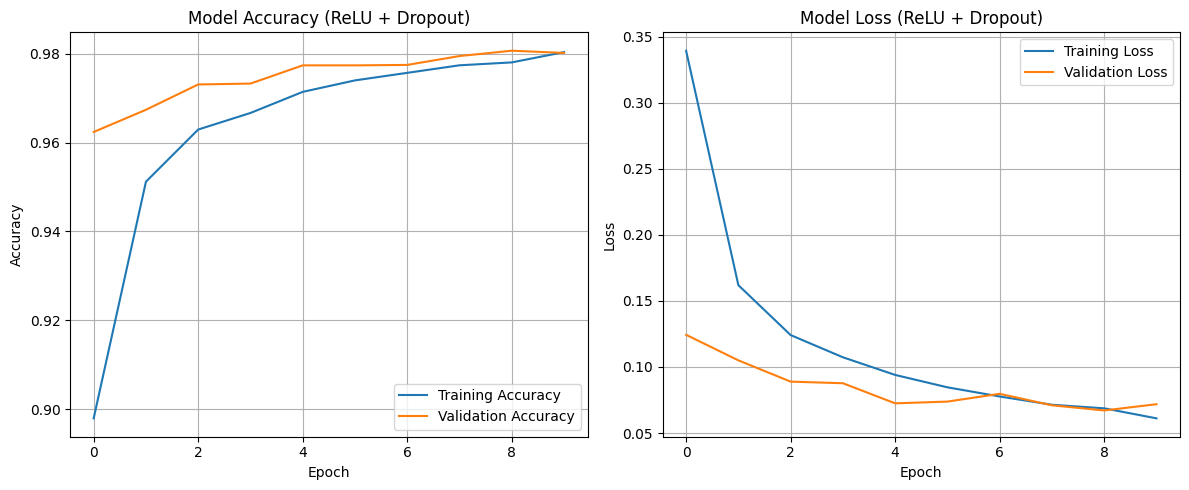


--- Running experiment with Sigmoid activation and Dropout (20%) ---
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7165 - loss: 0.9773 - val_accuracy: 0.9310 - val_loss: 0.2311
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9228 - loss: 0.2651 - val_accuracy: 0.9480 - val_loss: 0.1677
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9452 - loss: 0.1904 - val_accuracy: 0.9591 - val_loss: 0.1314
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9535 - loss: 0.1541 - val_accuracy: 0.9649 - val_loss: 0.1099
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9622 - loss: 0.1246 - val_accuracy: 0.9701 - val_loss: 0.0979
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9669 - loss: 0.1085 - val_accuracy: 0.9700 - val_loss: 0.0931
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9698 - loss: 0.0998 - val_accuracy: 0.9717 - val_loss: 0.0888
Epoch 8/10
1875

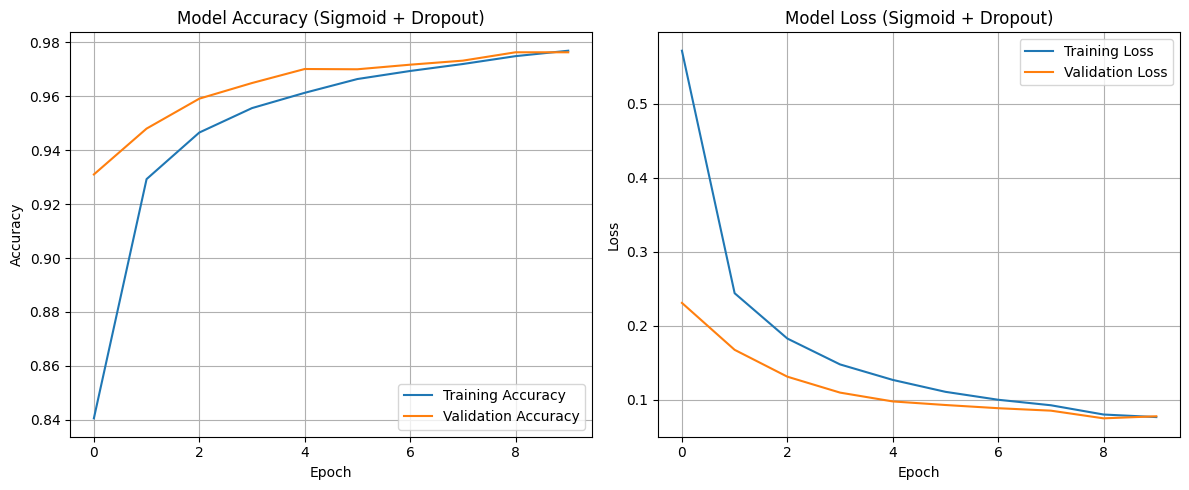

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Load and Prepare the MNIST Dataset ---
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

# Normalize pixel values from 0-255 to 0-1
train_images = train_images / 255.0
test_images = test_images / 255.0

# Flatten the 28x28 images into a 784-element vector
train_images = train_images.reshape(train_images.shape[0], 28 * 28)
test_images = test_images.reshape(test_images.shape[0], 28 * 28)

# --- 2. Function to Build, Train, and Evaluate the Model with Dropout ---
def run_experiment_with_dropout(activation_function_name, activation_function, dropout_rate=0.2):
    print(f"\n--- Running experiment with {activation_function_name} activation and Dropout ({dropout_rate*100:.0f}%) ---")

    # --- 3. Build the Neural Network Model with Dropout ---
    model = keras.Sequential([
        keras.Input(shape=(784,)), # Explicitly define the input layer
        keras.layers.Dense(128, activation=activation_function),
        keras.layers.Dropout(dropout_rate), # NEW: Dropout layer after the first hidden layer
        keras.layers.Dense(64, activation=activation_function),
        keras.layers.Dropout(dropout_rate), # NEW: Dropout layer after the second hidden layer
        keras.layers.Dense(10, activation='softmax')
    ])

    # --- 4. Compile the Model ---
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # --- 5. Train the Model ---
    history = model.fit(train_images, train_labels, epochs=10, batch_size=32,
                        validation_data=(test_images, test_labels))

    # --- 6. Evaluate the Model (on unseen test data) ---
    test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
    print(f'\nTest accuracy with {activation_function_name} and Dropout: {test_acc:.4f}')

    # --- 7. Plot Accuracy and Loss Curves ---
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Model Accuracy ({activation_function_name} + Dropout)')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Model Loss ({activation_function_name} + Dropout)')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# --- Run the experiments with different activation functions, now including dropout ---
# We'll use a dropout rate of 0.2 (20% of neurons dropped out randomly per update)
run_experiment_with_dropout('ReLU', 'relu', dropout_rate=0.2)
run_experiment_with_dropout('Sigmoid', 'sigmoid', dropout_rate=0.2)

# Optional: You can also try a higher dropout rate like 0.5 to see its effect
# run_experiment_with_dropout('ReLU', 'relu', dropout_rate=0.5)
# run_experiment_with_dropout('Sigmoid', 'sigmoid', dropout_rate=0.5)